In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import sqlalchemy
import flask
import sklearn

print("Pandas:", pd.__version__)
print("Sklearn:", sklearn.__version__)
print("SQLAlchemy:", sqlalchemy.__version__)
print("Flask:", flask.__version__)
print("All libraries loaded! ✅")

Pandas: 3.0.2
Sklearn: 1.8.0
SQLAlchemy: 2.0.49
Flask: 3.1.3
All libraries loaded! ✅


C:\Users\HASTINA REALTY\AppData\Local\Temp\ipykernel_15660\2516248264.py:14: DeprecationWarning: The '__version__' attribute is deprecated and will be removed in Flask 3.2. Use feature detection or 'importlib.metadata.version("flask")' instead.
  print("Flask:", flask.__version__)


In [3]:
# Load dataset
df = pd.read_csv('insurance_claims.csv')

print("Shape:", df.shape)
print("\nColumns:", list(df.columns))
print("\nFirst 5 rows:")
df.head()

Shape: (1000, 40)

Columns: ['months_as_customer', 'age', 'policy_number', 'policy_bind_date', 'policy_state', 'policy_csl', 'policy_deductable', 'policy_annual_premium', 'umbrella_limit', 'insured_zip', 'insured_sex', 'insured_education_level', 'insured_occupation', 'insured_hobbies', 'insured_relationship', 'capital-gains', 'capital-loss', 'incident_date', 'incident_type', 'collision_type', 'incident_severity', 'authorities_contacted', 'incident_state', 'incident_city', 'incident_location', 'incident_hour_of_the_day', 'number_of_vehicles_involved', 'property_damage', 'bodily_injuries', 'witnesses', 'police_report_available', 'total_claim_amount', 'injury_claim', 'property_claim', 'vehicle_claim', 'auto_make', 'auto_model', 'auto_year', 'fraud_reported', '_c39']

First 5 rows:


,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
0,328,48,521585,2014-10-17,OH,250/500,1000,1406.91,0,466132,...,YES,71610,6510,13020,52080,Saab,92x,2004,Y,NaN
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,...,?,5070,780,780,3510,Mercedes,E400,2007,Y,NaN
2,134,29,687698,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,...,NO,34650,7700,3850,23100,Dodge,RAM,2007,N,NaN
3,256,41,227811,1990-05-25,IL,250/500,2000,1415.74,6000000,608117,...,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Y,NaN
4,228,44,367455,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,...,NO,6500,1300,650,4550,Accura,RSX,2009,N,NaN


Fraud Distribution:
fraud_reported
N    753
Y    247
Name: count, dtype: int64


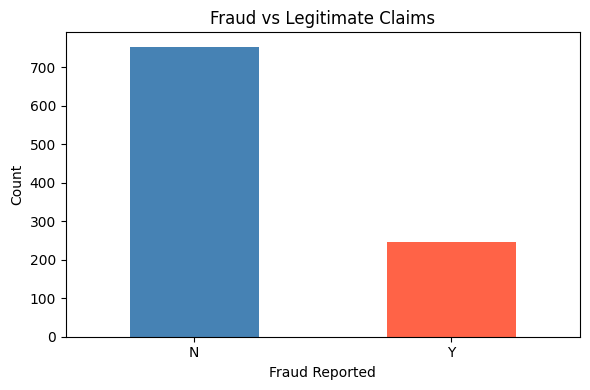

In [4]:
print("Fraud Distribution:")
print(df['fraud_reported'].value_counts())

# Visualize
plt.figure(figsize=(6,4))
df['fraud_reported'].value_counts().plot(kind='bar', color=['steelblue', 'tomato'])
plt.title('Fraud vs Legitimate Claims')
plt.xlabel('Fraud Reported')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [5]:
from sqlalchemy import create_engine, text
import sqlite3

# Create SQLite database
engine = create_engine('sqlite:///insurance_claims.db')

# Drop empty column and store in SQL
df_clean = df.drop(columns=['_c39'])

# Write to SQL table
df_clean.to_sql('claims', engine, if_exists='replace', index=False)

print("Database created! ✅")
print(f"Total records stored: {len(df_clean)}")

Database created! ✅
Total records stored: 1000


In [6]:
# Now let's query it like a real database!
with engine.connect() as conn:
    
    # Query 1 - Total claims by fraud status
    result1 = conn.execute(text("""
        SELECT fraud_reported, COUNT(*) as total_claims, 
               ROUND(AVG(total_claim_amount), 2) as avg_claim_amount
        FROM claims 
        GROUP BY fraud_reported
    """))
    print("=== Fraud vs Legitimate Claims ===")
    for row in result1:
        print(f"Fraud: {row[0]} | Count: {row[1]} | Avg Claim: ${row[2]}")

    # Query 2 - Top incident types in fraud cases
    result2 = conn.execute(text("""
        SELECT incident_type, COUNT(*) as count
        FROM claims
        WHERE fraud_reported = 'Y'
        GROUP BY incident_type
        ORDER BY count DESC
    """))
    print("\n=== Most Common Incident Types in Fraud Cases ===")
    for row in result2:
        print(f"{row[0]}: {row[1]} cases")

    # Query 3 - Fraud by vehicle make
    result3 = conn.execute(text("""
        SELECT auto_make, COUNT(*) as fraud_count
        FROM claims
        WHERE fraud_reported = 'Y'
        GROUP BY auto_make
        ORDER BY fraud_count DESC
        LIMIT 5
    """))
    print("\n=== Top 5 Car Makes in Fraud Cases ===")
    for row in result3:
        print(f"{row[0]}: {row[1]} cases")

=== Fraud vs Legitimate Claims ===
Fraud: N | Count: 753 | Avg Claim: $50288.61
Fraud: Y | Count: 247 | Avg Claim: $60302.11

=== Most Common Incident Types in Fraud Cases ===
Single Vehicle Collision: 117 cases
Multi-vehicle Collision: 114 cases
Vehicle Theft: 8 cases
Parked Car: 8 cases

=== Top 5 Car Makes in Fraud Cases ===
Mercedes: 22 cases
Ford: 22 cases
Chevrolet: 21 cases
Audi: 21 cases
Dodge: 20 cases


In [7]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Work with clean dataframe
data = df_clean.copy()

# Drop irrelevant columns
drop_cols = ['policy_number', 'policy_bind_date', 'incident_date', 
             'incident_location', 'insured_zip']
data = data.drop(columns=drop_cols)

# Handle missing values marked as '?'
data = data.replace('?', 'Unknown')

# Encode target variable
data['fraud_reported'] = data['fraud_reported'].map({'Y': 1, 'N': 0})

# Encode all categorical columns
le = LabelEncoder()
cat_cols = data.select_dtypes(include='object').columns
for col in cat_cols:
    data[col] = le.fit_transform(data[col].astype(str))

print("Preprocessing done! ✅")
print("Shape:", data.shape)
print("Fraud cases:", data['fraud_reported'].sum())

Preprocessing done! ✅
Shape: (1000, 34)
Fraud cases: 247


C:\Users\HASTINA REALTY\AppData\Local\Temp\ipykernel_15660\143602915.py:20: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = data.select_dtypes(include='object').columns


In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Split features and target
X = data.drop(columns=['fraud_reported'])
y = data['fraud_reported']

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Train Random Forest
model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',  # handles imbalanced data!
    random_state=42
)
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("=== Model Performance ===")
print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Fraud']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

=== Model Performance ===
              precision    recall  f1-score   support

  Legitimate       0.78      0.96      0.86       151
       Fraud       0.54      0.14      0.23        49

    accuracy                           0.76       200
   macro avg       0.66      0.55      0.54       200
weighted avg       0.72      0.76      0.70       200

ROC-AUC Score: 0.8184


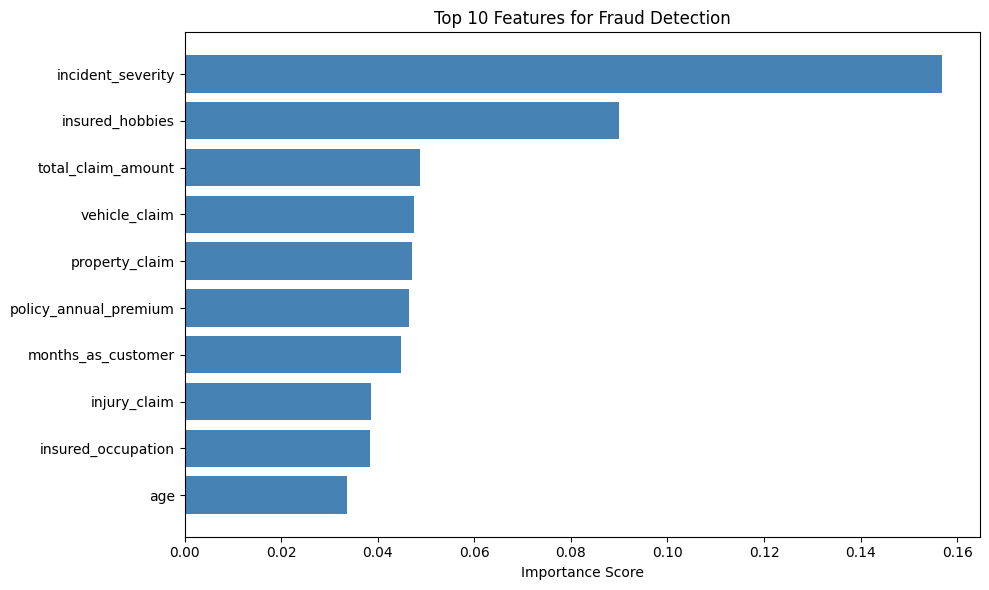

In [9]:
# Feature importance
importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['feature'], importance_df['importance'], color='steelblue')
plt.xlabel('Importance Score')
plt.title('Top 10 Features for Fraud Detection')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [10]:
from sklearn.metrics import classification_report

# Lower the decision threshold from 0.5 to 0.3
# This makes model more aggressive at catching fraud
y_pred_tuned = (y_prob >= 0.3).astype(int)

print("=== Tuned Model (threshold=0.3) ===")
print(classification_report(y_test, y_pred_tuned, 
      target_names=['Legitimate', 'Fraud']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

=== Tuned Model (threshold=0.3) ===
              precision    recall  f1-score   support

  Legitimate       0.93      0.79      0.86       151
       Fraud       0.56      0.82      0.67        49

    accuracy                           0.80       200
   macro avg       0.75      0.81      0.76       200
weighted avg       0.84      0.80      0.81       200

ROC-AUC Score: 0.8184


In [11]:
import joblib

joblib.dump(model, 'fraud_model.pkl')
joblib.dump(X.columns.tolist(), 'feature_columns.pkl')
print("Model saved! ✅")

Model saved! ✅
